<a href="https://colab.research.google.com/github/Nipun1a/Credit_predict/blob/main/Loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies



In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [55]:
#importing the dataset
loan_dataset = pd.read_csv('/content/loan_data.csv')

In [56]:
#printing the first 5 columns
loan_dataset.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [57]:
#print the last 5 columns
loan_dataset.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [58]:
#checking the null values
check = loan_dataset.isnull().sum()
print(check)
#there is no null values so we can proceed further work

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


In [59]:
X = loan_dataset.drop('loan_status', axis=1)
y = loan_dataset['loan_status']

Now, let's identify and encode the categorical features. We'll use `LabelEncoder` for binary categories and `OneHotEncoder` for multi-class categories.

In [60]:
# Define categorical and numerical columns for the ColumnTransformer
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
numerical_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

print(f"Categorical Features for Pipeline: {categorical_cols}")
print(f"Numerical Features for Pipeline: {numerical_cols}")

Categorical Features for Pipeline: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical Features for Pipeline: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


In [61]:
# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns not specified
)

print("ColumnTransformer preprocessor defined.")

ColumnTransformer preprocessor defined.


In [62]:
# Re-initialize X and y to ensure clean data for ColumnTransformer
X = loan_dataset.drop('loan_status', axis=1)
y = loan_dataset['loan_status']

# Re-split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")

Shape of X_train_processed: (36000, 27)
Shape of X_test_processed: (9000, 27)


Now that the data is preprocessed, let's split it into training and testing sets.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36000, 13)
X_test shape: (9000, 13)
y_train shape: (36000,)
y_test shape: (9000,)


Let's train and evaluate our models: Logistic Regression, Random Forest, and XGBoost.

In [64]:
# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_processed, y_train)

y_pred_lr = log_reg.predict(X_test_processed)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\n" + "="*50 + "\n")

Logistic Regression Performance:
Accuracy: 0.8993
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Confusion Matrix:
[[6599  401]
 [ 505 1495]]




In [65]:
# 2. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_processed, y_train)

y_pred_rf = rf_clf.predict(X_test_processed)

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\n" + "="*50 + "\n")

Random Forest Classifier Performance:
Accuracy: 0.9274
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.89      0.77      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

Confusion Matrix:
[[6814  186]
 [ 467 1533]]




In [66]:
# 3. XGBoost Classifier
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_processed, y_train)

y_pred_xgb = xgb_clf.predict(X_test_processed)

print("XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n" + "="*50 + "\n")

XGBoost Classifier Performance:
Accuracy: 0.9194
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      7000
           1       0.77      0.91      0.83      2000

    accuracy                           0.92      9000
   macro avg       0.87      0.91      0.89      9000
weighted avg       0.93      0.92      0.92      9000

Confusion Matrix:
[[6463  537]
 [ 188 1812]]




In [67]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

# Define the XGBoost classifier with initial parameters
# We maintain scale_pos_weight for class imbalance handling
xgb_clf_tuned = xgb.XGBClassifier(
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False # Suppress warning for future XGBoost versions
)

# Create a pipeline that includes preprocessing and the XGBoost model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb_model', xgb_clf_tuned)
])

# Define the parameter distribution for RandomizedSearchCV
params = {
    'xgb_model__n_estimators': [100, 200, 300, 400],
    'xgb_model__max_depth': [3, 5, 7, 9],
    'xgb_model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb_model__subsample': [0.6, 0.8, 1.0],
    'xgb_model__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb_model__gamma': [0, 0.1, 0.2],
    'xgb_model__lambda': [0.5, 1, 1.5],
    'xgb_model__alpha': [0, 0.1, 0.2]
}

# Initialize RandomizedSearchCV
# Using 'f1' as scoring metric because of potential class imbalance
# n_jobs=-1 to use all available cores
search = RandomizedSearchCV(
    pipeline,
    param_distributions=params,
    n_iter=20, # Number of parameter settings that are sampled
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting RandomizedSearchCV for XGBoost...")
search.fit(X_train, y_train)
print("RandomizedSearchCV completed.")


Starting RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV completed.


### Best XGBoost Model from Randomized Search

Let's examine the best parameters found by `RandomizedSearchCV` and evaluate the performance of the optimized model.

In [68]:
# Get the best model
best_model = search.best_estimator_

print("Best parameters found by RandomizedSearchCV:")
print(search.best_params_)
print(f"\nBest F1-score from RandomizedSearchCV: {search.best_score_:.4f}")

# Make predictions with the best model on the test set
y_pred_tuned_xgb = best_model.predict(X_test)

print("\nOptimized XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned_xgb):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_xgb))
print("\n" + "="*50 + "\n")

Best parameters found by RandomizedSearchCV:
{'xgb_model__subsample': 0.8, 'xgb_model__n_estimators': 400, 'xgb_model__max_depth': 5, 'xgb_model__learning_rate': 0.2, 'xgb_model__lambda': 1.5, 'xgb_model__gamma': 0, 'xgb_model__colsample_bytree': 0.6, 'xgb_model__alpha': 0.1}

Best F1-score from RandomizedSearchCV: 0.8336

Optimized XGBoost Classifier Performance:
Accuracy: 0.9258
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      7000
           1       0.80      0.90      0.84      2000

    accuracy                           0.93      9000
   macro avg       0.88      0.91      0.90      9000
weighted avg       0.93      0.93      0.93      9000

Confusion Matrix:
[[6542  458]
 [ 210 1790]]




### Feature Importance from Optimized XGBoost Model

Let's visualize the feature importances to understand which features contribute most to the model's predictions.

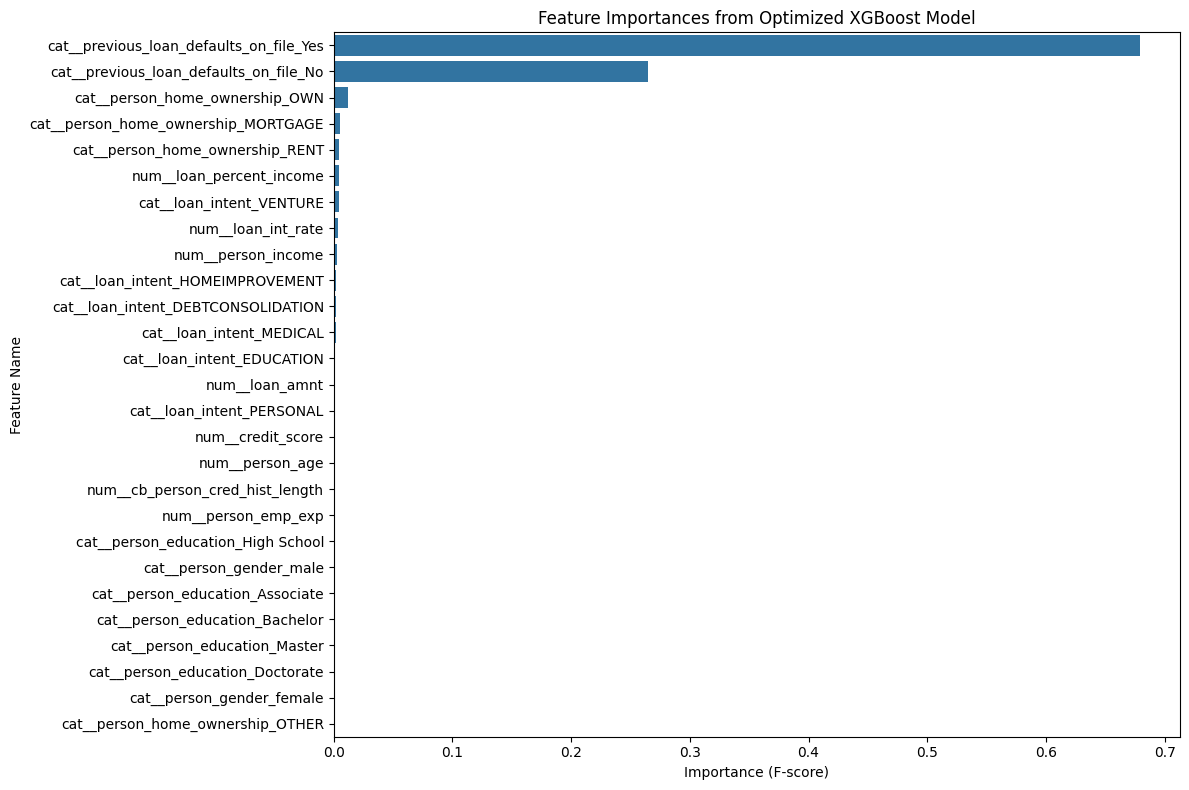

In [69]:
# Get feature importances from the best XGBoost model in the pipeline
# The best_model is a Pipeline, so we access the xgb_model step
feature_importances = best_model.named_steps['xgb_model'].feature_importances_

# Get feature names after preprocessing
# preprocessor.get_feature_names_out() returns names for all transformed features
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Optimized XGBoost Model')
plt.xlabel('Importance (F-score)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Custom Threshold Optimization for XGBoost Model

Given that false negatives (predicting no default when a default actually occurs) are particularly dangerous in loan prediction, let's explore how different classification thresholds impact the model's performance, especially recall for the positive class (loan default).

In [70]:
# Calculate prediction probabilities for the positive class (class 1)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Define a range of thresholds to explore
thresholds = np.arange(0.1, 1.0, 0.05) # From 0.1 to 0.95 with step 0.05

print("Evaluating model performance across different thresholds:")
for threshold in thresholds:
    # Apply the custom threshold to probabilities to get predicted classes
    y_pred_threshold = (y_prob > threshold).astype(int)

    print(f"\n--- Threshold: {threshold:.2f} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_threshold))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_threshold))


Evaluating model performance across different thresholds:

--- Threshold: 0.10 ---
Accuracy: 0.8464
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7000
           1       0.59      0.97      0.74      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.89      0.81      9000
weighted avg       0.90      0.85      0.86      9000

Confusion Matrix:
[[5673 1327]
 [  55 1945]]

--- Threshold: 0.15 ---
Accuracy: 0.8656
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7000
           1       0.63      0.97      0.76      2000

    accuracy                           0.87      9000
   macro avg       0.81      0.90      0.83      9000
weighted avg       0.91      0.87      0.87      9000

Confusion Matrix:
[[5857 1143]
 [  67 1933]]

--- Threshold: 0.20 ---
Accuracy: 0.8778
Classification Report:
   

By examining the classification reports and confusion matrices for each threshold, you can identify a point where the recall for class 1 (loan default) is acceptably high, even if it means a slight reduction in precision or an increase in false positives. The goal is to find a balance that aligns with the business cost of false negatives versus false positives.

In [71]:
import joblib

# Save the best model (XGBoost in this case)
joblib.dump(xgb_clf, 'model.pkl')

print("Model 'model.pkl' saved successfully!")

Model 'model.pkl' saved successfully!


Now you can download the `model.pkl` file.

### Model Comparison Summary

Based on the performance metrics above, you can compare the accuracy, precision, recall, and F1-score of each model to determine which one performs best for this dataset.

In [72]:
from google.colab import files
#files.download('model.pkl')
